In [1]:
import sys

assert sys.version_info >= (3, 7)
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
import tensorflow as tf

# assert version.parse(tf.__version__) >= version.parse("2.8.0")
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ann"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# From Biological to Artificial Neurons

## The Perceptron

In [3]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0)  # Iris setosa

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

X_new = [[2, 0.5], [3, 1]]
y_pred = per_clf.predict(X_new)  # predicts True and False for these 2 flowers

In [4]:
y_pred

array([ True, False])

The Perceptron is equivalent to a SGDClassifier with loss="perceptron", no regularization, and a constant learning rate equal to 1:

In [5]:
# extra code – shows how to build and train a Perceptron

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(loss="perceptron", penalty=None,
                        learning_rate="constant", eta0=1, random_state=42)
sgd_clf.fit(X, y)
assert (sgd_clf.coef_ == per_clf.coef_).all()
assert (sgd_clf.intercept_ == per_clf.intercept_).all()

When the Perceptron finds a decision boundary that properly separates the classes, it stops learning. This means that the decision boundary is often quite close to one class:

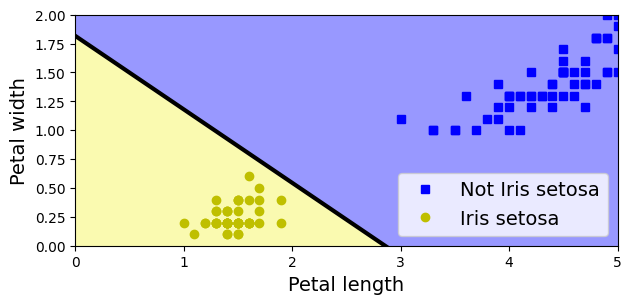

In [6]:
# extra code – plots the decision boundary of a Perceptron on the iris dataset

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

a = -per_clf.coef_[0, 0] / per_clf.coef_[0, 1]
b = -per_clf.intercept_ / per_clf.coef_[0, 1]
axes = [0, 5, 0, 2]
x0, x1 = np.meshgrid(
    np.linspace(axes[0], axes[1], 500).reshape(-1, 1),
    np.linspace(axes[2], axes[3], 200).reshape(-1, 1),
)
X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = per_clf.predict(X_new)
zz = y_predict.reshape(x0.shape)
custom_cmap = ListedColormap(['#9898ff', '#fafab0'])

plt.figure(figsize=(7, 3))
plt.plot(X[y == 0, 0], X[y == 0, 1], "bs", label="Not Iris setosa")
plt.plot(X[y == 1, 0], X[y == 1, 1], "yo", label="Iris setosa")
plt.plot([axes[0], axes[1]], [a * axes[0] + b, a * axes[1] + b], "k-",
         linewidth=3)
plt.contourf(x0, x1, zz, cmap=custom_cmap)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="lower right")
plt.axis(axes)
plt.show()

## Activation functions

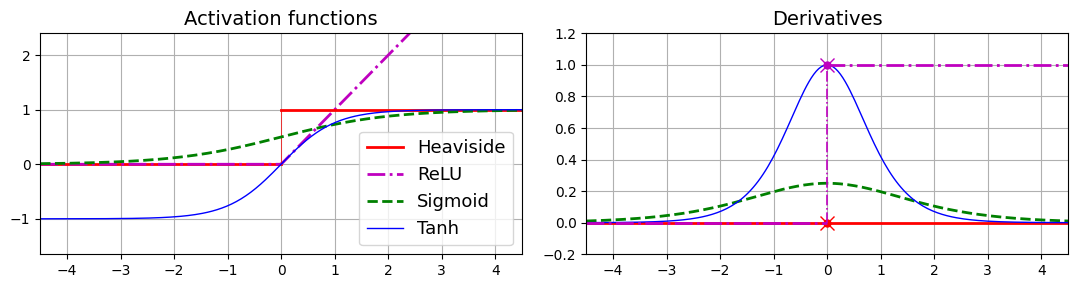

In [7]:
# extra code – this cell generates and saves Figure 10–8

from scipy.special import expit as sigmoid

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

max_z = 4.5
z = np.linspace(-max_z, max_z, 200)

plt.figure(figsize=(11, 3.1))

plt.subplot(121)
plt.plot([-max_z, 0], [0, 0], "r-", linewidth=2, label="Heaviside")
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")
plt.plot([0, 0], [0, 1], "r-", linewidth=0.5)
plt.plot([0, max_z], [1, 1], "r-", linewidth=2)
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, np.tanh(z), "b-", linewidth=1, label="Tanh")
plt.grid(True)
plt.title("Activation functions")
plt.axis([-max_z, max_z, -1.65, 2.4])
plt.gca().set_yticks([-1, 0, 1, 2])
plt.legend(loc="lower right", fontsize=13)

plt.subplot(122)
plt.plot(z, derivative(np.sign, z), "r-", linewidth=2, label="Heaviside")
plt.plot(0, 0, "ro", markersize=5)
plt.plot(0, 0, "rx", markersize=10)
plt.plot(z, derivative(sigmoid, z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, derivative(np.tanh, z), "b-", linewidth=1, label="Tanh")
plt.plot([-max_z, 0], [0, 0], "m-.", linewidth=2)
plt.plot([0, max_z], [1, 1], "m-.", linewidth=2)
plt.plot([0, 0], [0, 1], "m-.", linewidth=1.2)
plt.plot(0, 1, "mo", markersize=5)
plt.plot(0, 1, "mx", markersize=10)
plt.grid(True)
plt.title("Derivatives")
plt.axis([-max_z, max_z, -0.2, 1.2])

save_fig("activation_functions_plot")
plt.show()

# Regression MLPs

Warning: In recent versions of Scikit-Learn, you must use root_mean_squared_error() to compute the RMSE, instead of mean_squared_error(labels, predictions, squared=False). The following try/except block tries to import root_mean_squared_error, and if it fails it just defines it.

In [8]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

In [9]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)
rmse = root_mean_squared_error(y_valid, y_pred)

In [10]:
rmse

0.5053326657968585

# Classification MLPs

In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

iris = load_iris()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    iris.data, iris.target, test_size=0.1, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42)

mlp_clf = MLPClassifier(hidden_layer_sizes=[5], max_iter=10_000,
                        random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_clf)
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_valid, y_valid)
accuracy

1.0

# Implementing MLPs with Keras
## Building an Image Classifier Using the Sequential API
## Using Keras to load the dataset

Let's start by loading the fashion MNIST dataset. Keras has a number of functions to load popular datasets in tf.keras.datasets. The dataset is already split for you between a training set (60,000 images) and a test set (10,000 images), but it can be useful to split the training set further to have a validation set. We'll use 55,000 images for training, and 5,000 for validation.

In [12]:
import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

The training set contains 60,000 grayscale images, each 28x28 pixels:

In [13]:
X_train.shape

(55000, 28, 28)

Each pixel intensity is represented as a byte (0 to 255):

In [14]:
X_train.dtype

dtype('uint8')

Let's scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255:

In [15]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

You can plot an image using Matplotlib's imshow() function, with a 'binary' color map:

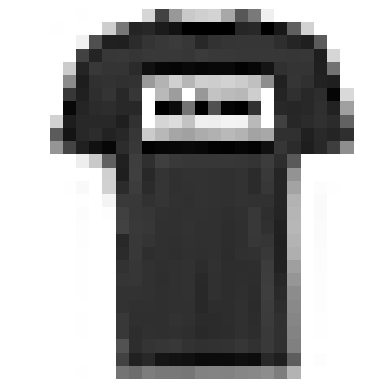

In [16]:
plt.imshow(X_train[1], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9:

In [17]:
y_train

array([9, 0, 0, ..., 9, 0, 2], dtype=uint8)

In [18]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

So the first image in the training set is an ankle boot:

In [19]:
class_names[y_train[0]]

'Ankle boot'

Let's take a look at a sample of the images in the dataset:

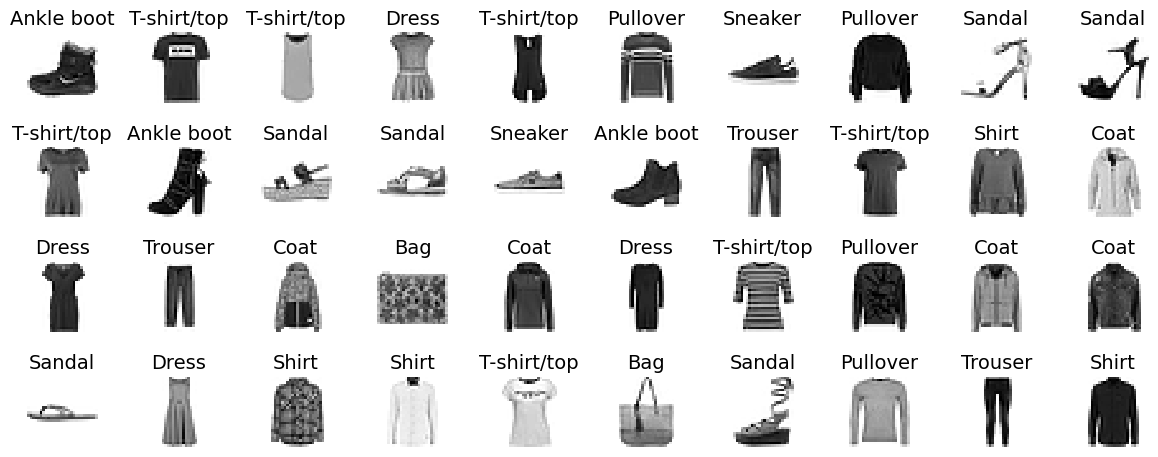

In [20]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

save_fig("fashion_mnist_plot")
plt.show()

## Creating the model using the Sequential API

In [21]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(input_shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [22]:
# extra code – clear the session to reset the name counters
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


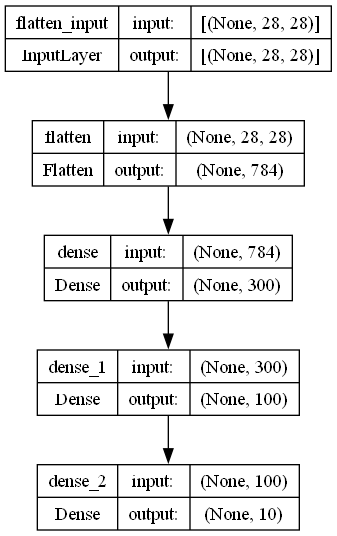

In [24]:
# extra code – another way to display the model's architecture
tf.keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True)

In [25]:
model.layers

In [26]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [27]:
model.get_layer('dense') is hidden1

True

In [28]:
weights, biases = hidden1.get_weights()
weights

array([[ 0.01732439,  0.02115615, -0.03229556, ...,  0.06514744,
        -0.01798373,  0.0342562 ],
       [ 0.00253146, -0.03208449,  0.00567285, ...,  0.0401999 ,
         0.01701246,  0.02238097],
       [ 0.0045606 , -0.01593269,  0.00456892, ...,  0.05645081,
        -0.02181416, -0.0708707 ],
       ...,
       [-0.03250148, -0.02523903, -0.00709926, ...,  0.02279951,
         0.06966811,  0.00662041],
       [ 0.0264561 , -0.02053792, -0.0159839 , ...,  0.01145986,
         0.02525482,  0.05044541],
       [-0.04691393, -0.03649583,  0.05145347, ..., -0.03235596,
         0.06591332, -0.05332366]], dtype=float32)

In [29]:
weights.shape

(784, 300)

In [30]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [31]:
biases.shape

(300,)

## Compiling the model

In [32]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [33]:
# extra code – this cell is equivalent to the previous cell
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

In [34]:
# extra code – shows how to convert class ids to one-hot vectors
tf.keras.utils.to_categorical([0, 5, 1, 0], num_classes=10)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

Note: it's important to set num_classes when the number of classes is greater than the maximum class id in the sample.

In [35]:
# extra code – shows how to convert one-hot vectors to class ids
np.argmax(
    [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
     [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
     [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
    axis=1
)

array([0, 5, 1, 0], dtype=int64)

## Training and evaluating the model

In [36]:
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

Epoch 1/30


1719/1719 [==============================] - 20s 9ms/step - loss: 0.7395 - sparse_categorical_accuracy: 0.7557 - val_loss: 0.5112 - val_sparse_categorical_accuracy: 0.8250
Epoch 2/30
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4899 - sparse_categorical_accuracy: 0.8313 - val_loss: 0.4673 - val_sparse_categorical_accuracy: 0.8298
Epoch 3/30
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4435 - sparse_categorical_accuracy: 0.8446 - val_loss: 0.4295 - val_sparse_categorical_accuracy: 0.8486
Epoch 4/30
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4190 - sparse_categorical_accuracy: 0.8540 - val_loss: 0.3993 - val_sparse_categorical_accuracy: 0.8570
Epoch 5/30
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3985 - sparse_categorical_accuracy: 0.8606 - val_loss: 0.3951 - val_sparse_categorical_accuracy: 0.8592
Epoch 6/30
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3822 - sp

In [37]:
history.params

{'verbose': 1, 'epochs': 30, 'steps': 1719}

In [38]:
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


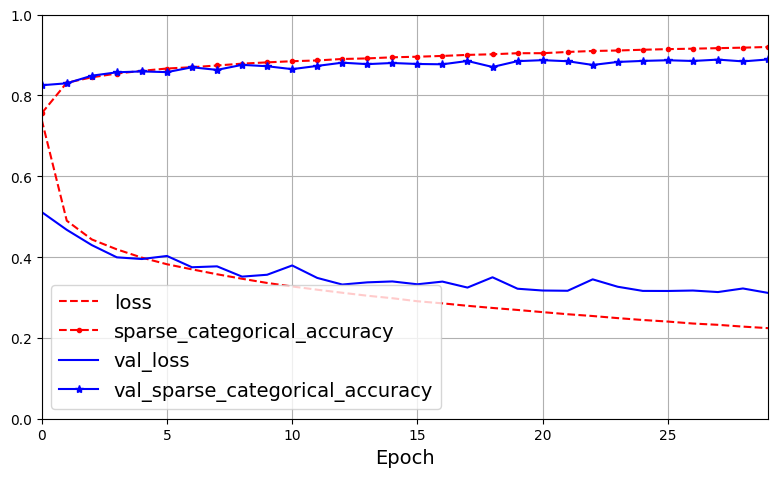

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code
save_fig("keras_learning_curves_plot")  # extra code
plt.show()

In [40]:
history.history.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

In [41]:
pd.DataFrame(history.history)

,loss,sparse_categorical_accuracy,val_loss,val_sparse_categorical_accuracy
0,0.739513,0.755655,0.511198,0.8250
1,0.489868,0.831273,0.467305,0.8298
2,0.443483,0.844564,0.429485,0.8486
3,0.418977,0.854000,0.399252,0.8570
4,0.398486,0.860600,0.395080,0.8592
5,0.382177,0.866364,0.402648,0.8574
6,0.369494,0.869618,0.374704,0.8694
7,0.357420,0.873855,0.376981,0.8630
8,0.346258,0.878418,0.351538,0.8754
9,0.335894,0.881582,0.356158,0.8720


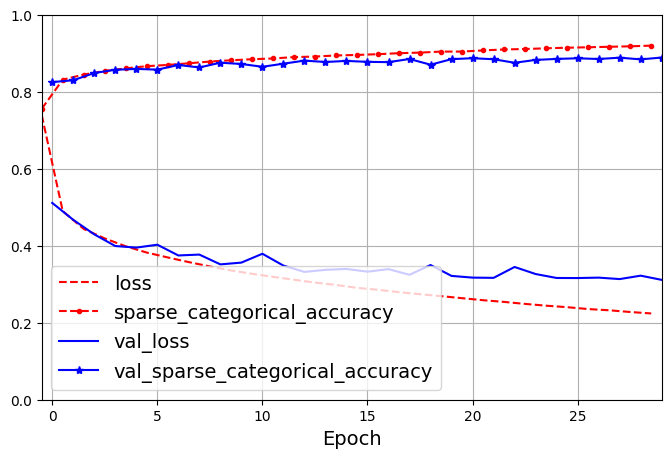

In [42]:
# extra code – shows how to shift the training curve by -1/2 epoch
plt.figure(figsize=(8, 5))
for key, style in zip(history.history, ["r--", "r--.", "b-", "b-*"]):
    epochs = np.array(history.epoch) + (0 if key.startswith("val_") else -0.5)
    plt.plot(epochs, history.history[key], style, label=key)
plt.xlabel("Epoch")
plt.axis([-0.5, 29, 0., 1])
plt.legend(loc="lower left")
plt.grid()
plt.show()

In [43]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 1s 4ms/step - loss: 0.3270 - sparse_categorical_accuracy: 0.8837


[0.326961874961853, 0.8837000131607056]

## Using the model to make predictions

In [44]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 [==============================] - 1s 595ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.02, 0.  , 0.97],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [45]:
y_pred = y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1], dtype=int64)

In [46]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [47]:
y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

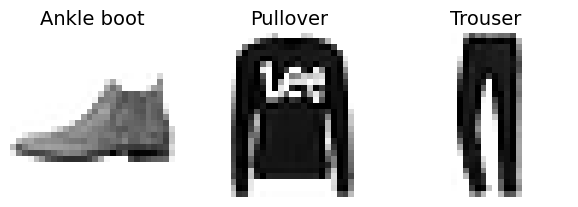

In [48]:
# extra code – this cell generates and saves Figure 10–12
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
save_fig('fashion_mnist_images_plot', tight_layout=False)
plt.show()

## Building a Regression MLP Using the Sequential API

Let's load, split and scale the California housing dataset (the original one, not the modified one as in chapter 2):

In [49]:
# extra code – load and split the California housing dataset, like earlier
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

In [50]:
tf.random.set_seed(42)
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])
model = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
norm_layer.adapt(X_train)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))
mse_test, rmse_test = model.evaluate(X_test, y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)

Epoch 1/20
363/363 [==============================] - 4s 6ms/step - loss: 0.8422 - root_mean_squared_error: 0.9177 - val_loss: 0.4129 - val_root_mean_squared_error: 0.6426
Epoch 2/20
363/363 [==============================] - 2s 5ms/step - loss: 0.3719 - root_mean_squared_error: 0.6098 - val_loss: 1.7856 - val_root_mean_squared_error: 1.3363
Epoch 3/20
363/363 [==============================] - 2s 4ms/step - loss: 0.3592 - root_mean_squared_error: 0.5993 - val_loss: 0.3542 - val_root_mean_squared_error: 0.5952
Epoch 4/20
363/363 [==============================] - 2s 4ms/step - loss: 0.3383 - root_mean_squared_error: 0.5817 - val_loss: 0.3796 - val_root_mean_squared_error: 0.6161
Epoch 5/20
363/363 [==============================] - 2s 4ms/step - loss: 0.3258 - root_mean_squared_error: 0.5708 - val_loss: 0.3892 - val_root_mean_squared_error: 0.6238
Epoch 6/20
363/363 [==============================] - 2s 4ms/step - loss: 0.3153 - root_mean_squared_error: 0.5615 - val_loss: 0.9627 - val_

In [51]:
rmse_test

0.5309882164001465

In [52]:
y_pred

array([[0.4995014],
       [1.0899796],
       [5.3193893]], dtype=float32)

In [53]:
y_test[:3]

array([0.477  , 0.458  , 5.00001])

## Building Complex Models Using the Functional API

Not all neural network models are simply sequential. Some may have complex topologies. Some may have multiple inputs and/or multiple outputs. For example, a Wide & Deep neural network (see paper) connects all or part of the inputs directly to the output layer.

In [54]:
# extra code – reset the name counters and make the code reproducible
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [55]:
normalization_layer = tf.keras.layers.Normalization()
hidden_layer1 = tf.keras.layers.Dense(30, activation="relu")
hidden_layer2 = tf.keras.layers.Dense(30, activation="relu")
concat_layer = tf.keras.layers.Concatenate()
output_layer = tf.keras.layers.Dense(1)

input_ = tf.keras.layers.Input(shape=X_train.shape[1:])
normalized = normalization_layer(input_)
hidden1 = hidden_layer1(normalized)
hidden2 = hidden_layer2(hidden1)
concat = concat_layer([normalized, hidden2])
output = output_layer(concat)

model = tf.keras.Model(inputs=[input_], outputs=[output])

In [56]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 8)]                  0         []                            
                                                                                                  
 normalization (Normalizati  (None, 8)                    17        ['input_1[0][0]']             
 on)                                                                                              
                                                                                                  
 dense (Dense)               (None, 30)                   270       ['normalization[0][0]']       
                                                                                                  
 dense_1 (Dense)             (None, 30)                   930       ['dense[0][0]']           

In [57]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
normalization_layer.adapt(X_train)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)
y_pred = model.predict(X_new)

Epoch 1/20
363/363 [==============================] - 3s 5ms/step - loss: 1.3563 - root_mean_squared_error: 1.1646 - val_loss: 0.7370 - val_root_mean_squared_error: 0.8585
Epoch 2/20
363/363 [==============================] - 1s 4ms/step - loss: 0.4654 - root_mean_squared_error: 0.6822 - val_loss: 0.6739 - val_root_mean_squared_error: 0.8209
Epoch 3/20
363/363 [==============================] - 1s 4ms/step - loss: 0.4010 - root_mean_squared_error: 0.6333 - val_loss: 0.5829 - val_root_mean_squared_error: 0.7634
Epoch 4/20
363/363 [==============================] - 1s 4ms/step - loss: 0.3766 - root_mean_squared_error: 0.6137 - val_loss: 0.3711 - val_root_mean_squared_error: 0.6092
Epoch 5/20
363/363 [==============================] - 2s 4ms/step - loss: 0.3694 - root_mean_squared_error: 0.6078 - val_loss: 0.3726 - val_root_mean_squared_error: 0.6104
Epoch 6/20
363/363 [==============================] - 1s 4ms/step - loss: 0.3522 - root_mean_squared_error: 0.5935 - val_loss: 0.5502 - val_

What if you want to send different subsets of input features through the wide or deep paths? We will send 5 features (features 0 to 4), and 6 through the deep path (features 2 to 7). Note that 3 features will go through both (features 2, 3 and 4).

In [58]:
tf.random.set_seed(42)  # extra code

In [59]:
input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output])

In [60]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:]
X_valid_wide, X_valid_deep = X_valid[:, :5], X_valid[:, 2:]
X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:]
X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model.fit((X_train_wide, X_train_deep), y_train, epochs=20,
                    validation_data=((X_valid_wide, X_valid_deep), y_valid))
mse_test = model.evaluate((X_test_wide, X_test_deep), y_test)
y_pred = model.predict((X_new_wide, X_new_deep))

Epoch 1/20
363/363 [==============================] - 3s 5ms/step - loss: 1.6857 - root_mean_squared_error: 1.2983 - val_loss: 1.2788 - val_root_mean_squared_error: 1.1309
Epoch 2/20
363/363 [==============================] - 2s 4ms/step - loss: 0.5613 - root_mean_squared_error: 0.7492 - val_loss: 0.6080 - val_root_mean_squared_error: 0.7797
Epoch 3/20
363/363 [==============================] - 2s 4ms/step - loss: 0.4671 - root_mean_squared_error: 0.6835 - val_loss: 0.5172 - val_root_mean_squared_error: 0.7191
Epoch 4/20
363/363 [==============================] - 2s 5ms/step - loss: 0.4230 - root_mean_squared_error: 0.6504 - val_loss: 0.5285 - val_root_mean_squared_error: 0.7270
Epoch 5/20
363/363 [==============================] - 2s 5ms/step - loss: 0.3956 - root_mean_squared_error: 0.6289 - val_loss: 0.5484 - val_root_mean_squared_error: 0.7406
Epoch 6/20
363/363 [==============================] - 2s 4ms/step - loss: 0.3789 - root_mean_squared_error: 0.6156 - val_loss: 0.4428 - val_

Adding an auxiliary output for regularization:

In [61]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [62]:
input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
aux_output = tf.keras.layers.Dense(1)(hidden2)
model = tf.keras.Model(inputs=[input_wide, input_deep],
                       outputs=[output, aux_output])

Warning: in recent versions, Keras requires one metric per output, so I replaced metrics=["RootMeanSquaredError"] with metrics=["RootMeanSquaredError", "RootMeanSquaredError"] in the code below.

In [63]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=("mse", "mse"), loss_weights=(0.9, 0.1), optimizer=optimizer,
              metrics=["RootMeanSquaredError"])

In [64]:
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=20,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid))
)

Epoch 1/20
363/363 [==============================] - 5s 6ms/step - loss: 1.6184 - dense_2_loss: 1.5757 - dense_3_loss: 2.0029 - dense_2_root_mean_squared_error: 1.2553 - dense_3_root_mean_squared_error: 1.4152 - val_loss: 1.5161 - val_dense_2_loss: 1.4218 - val_dense_3_loss: 2.3653 - val_dense_2_root_mean_squared_error: 1.1924 - val_dense_3_root_mean_squared_error: 1.5380
Epoch 2/20
363/363 [==============================] - 2s 5ms/step - loss: 0.5617 - dense_2_loss: 0.5304 - dense_3_loss: 0.8435 - dense_2_root_mean_squared_error: 0.7283 - dense_3_root_mean_squared_error: 0.9184 - val_loss: 0.8419 - val_dense_2_loss: 0.7713 - val_dense_3_loss: 1.4775 - val_dense_2_root_mean_squared_error: 0.8782 - val_dense_3_root_mean_squared_error: 1.2155
Epoch 3/20
363/363 [==============================] - 2s 5ms/step - loss: 0.4695 - dense_2_loss: 0.4455 - dense_3_loss: 0.6858 - dense_2_root_mean_squared_error: 0.6675 - dense_3_root_mean_squared_error: 0.8281 - val_loss: 0.5133 - val_dense_2_loss

Warning: in recent TF version, evaluate() also returns the main metric and the aux metric. To ensure the code works in both old and new versions, we only look at the first 3 elements of eval_results (i.e., just the losses):

In [65]:
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
weighted_sum_of_losses, main_loss, aux_loss = eval_results[:3]

162/162 [==============================] - 1s 4ms/step - loss: 0.3385 - dense_2_loss: 0.3318 - dense_3_loss: 0.3989 - dense_2_root_mean_squared_error: 0.5760 - dense_3_root_mean_squared_error: 0.6316


In [66]:
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

1/1 [==============================] - 0s 209ms/step


In [67]:
y_pred_main

array([[0.26339093],
       [1.1680061 ],
       [3.4513454 ]], dtype=float32)

In [68]:
y_test[:3]

array([0.477  , 0.458  , 5.00001])

In [69]:
y_pred_tuple = model.predict((X_new_wide, X_new_deep))
y_pred = dict(zip(model.output_names, y_pred_tuple))

1/1 [==============================] - 0s 62ms/step


## Using the Subclassing API to Build Dynamic Models

In [70]:
class WideAndDeepModel(tf.keras.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)  # needed to support naming the model
        self.norm_layer_wide = tf.keras.layers.Normalization()
        self.norm_layer_deep = tf.keras.layers.Normalization()
        self.hidden1 = tf.keras.layers.Dense(units, activation=activation)
        self.hidden2 = tf.keras.layers.Dense(units, activation=activation)
        self.main_output = tf.keras.layers.Dense(1)
        self.aux_output = tf.keras.layers.Dense(1)
        
    def call(self, inputs):
        input_wide, input_deep = inputs
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)
        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1)
        concat = tf.keras.layers.concatenate([norm_wide, hidden2])
        output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return output, aux_output

tf.random.set_seed(42)  # extra code – just for reproducibility
model = WideAndDeepModel(30, activation="relu", name="my_cool_model")

In [71]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer=optimizer,
              metrics=["RootMeanSquaredError"])
model.norm_layer_wide.adapt(X_train_wide)
model.norm_layer_deep.adapt(X_train_deep)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)))
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

Epoch 1/10
363/363 [==============================] - 5s 7ms/step - loss: 1.2623 - output_1_loss: 1.1878 - output_2_loss: 1.9330 - output_1_root_mean_squared_error: 1.0899 - output_2_root_mean_squared_error: 1.3903 - val_loss: 0.9183 - val_output_1_loss: 0.7375 - val_output_2_loss: 2.5461 - val_output_1_root_mean_squared_error: 0.8588 - val_output_2_root_mean_squared_error: 1.5957
Epoch 2/10
363/363 [==============================] - 2s 5ms/step - loss: 0.5089 - output_1_loss: 0.4804 - output_2_loss: 0.7660 - output_1_root_mean_squared_error: 0.6931 - output_2_root_mean_squared_error: 0.8752 - val_loss: 0.6741 - val_output_1_loss: 0.5980 - val_output_2_loss: 1.3592 - val_output_1_root_mean_squared_error: 0.7733 - val_output_2_root_mean_squared_error: 1.1659
Epoch 3/10
363/363 [==============================] - 2s 5ms/step - loss: 0.4544 - output_1_loss: 0.4333 - output_2_loss: 0.6441 - output_1_root_mean_squared_error: 0.6583 - output_2_root_mean_squared_error: 0.8026 - val_loss: 0.481

## Saving and Restoring a Model

Warning: Keras now recommends using the .keras format to save models, and the h5 format for weights. Therefore I have updated the code in this section to first show what you need to change if you still want to use TensorFlow's SavedModel format, and then how you can use the recommended formats.

In [72]:
# extra code – delete the directory, in case it already exists

import shutil

shutil.rmtree("my_keras_model", ignore_errors=True)

Warning: Keras's model.save() method no longer supports TensorFlow's SavedModel format. However, you can still export models to the SavedModel format using model.export() like this:

In [73]:
model.export("my_keras_model")

INFO:tensorflow:Assets written to: my_keras_model\assets


INFO:tensorflow:Assets written to: my_keras_model\assets


Saved artifact at 'my_keras_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Tuple[TensorSpec(shape=(None, 5), dtype=tf.float32, name='input_1'), TensorSpec(shape=(None, 6), dtype=tf.float32, name='input_2')]
Output Type:
  Tuple[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2192895292240: TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)
  2192895292624: TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)
  2192663441680: TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
  2192663431504: TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
  2192663434384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2192663434000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2192663433616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2192663432272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2192663434576: TensorSpec(shape=(), dtyp

In [74]:
# extra code – show the contents of the my_keras_model/ directory
for path in sorted(Path("my_keras_model").glob("**/*")):
    print(path)

my_keras_model\assets
my_keras_model\fingerprint.pb
my_keras_model\saved_model.pb
my_keras_model\variables
my_keras_model\variables\variables.data-00000-of-00001
my_keras_model\variables\variables.index


Warning: In Keras 3, it is no longer possible to load a TensorFlow SavedModel as a Keras model. However, you can load a SavedModel as a tf.keras.layers.TFSMLayer layer, but be aware that this layer can only be used for inference: no training.

In [83]:
# New keras version support below given code

# tfsm_layer = tf.keras.layers.TFSMLayer("my_keras_model")
# y_pred_main, y_pred_aux = tfsm_layer((X_new_wide, X_new_deep))


# Alternate for the above

loaded = tf.saved_model.load("my_keras_model")
infer = loaded.signatures["serving_default"]

preds = infer(
    input_1=tf.constant(X_new_wide, dtype=tf.float32),
    input_2=tf.constant(X_new_deep, dtype=tf.float32)
)

y_pred_main = preds["output_0"]
y_pred_aux  = preds["output_1"]

Warning: Keras now requires the saved weights to have the .weights.h5 extension. There are no longer saved using the SavedModel format.

In [79]:
# model.save_weights("my_weights.weights.h5")

# Alternate to above:

tf.saved_model.save(loaded, "my_model_copy")

INFO:tensorflow:Assets written to: my_model_copy\assets


INFO:tensorflow:Assets written to: my_model_copy\assets


In [ ]:
# model.load_weights("my_weights.weights.h5")

# Alternate to above:

infer = loaded.signatures["serving_default"]

preds = infer(
    input_1=tf.constant(X_new_wide, dtype=tf.float32),
    input_2=tf.constant(X_new_deep, dtype=tf.float32)
)

To save a model using the .keras format, simply use model.save():

In [ ]:
# model.save("my_model.keras")

loaded.save("my_model.keras")

AttributeError: '_UserObject' object has no attribute 'save'

To load a .keras model, use the tf.keras.models.load_model() function. If the model uses any custom object, you must pass them to the function via the custom_objects argument:

In [85]:
loaded_model = tf.keras.models.load_model(
    "my_model.keras",
    custom_objects={"WideAndDeepModel": WideAndDeepModel}
)

OSError: No file or directory found at my_model.keras

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.15.0


## Using Callbacks

In [88]:
shutil.rmtree("my_checkpoints", ignore_errors=True)  # extra code

In [89]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_checkpoints.weights.h5",
                                                   save_weights_only=True)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[checkpoint_cb])

Epoch 1/10
363/363 [==============================] - 2s 5ms/step - loss: 0.3673 - output_1_loss: 0.3595 - output_2_loss: 0.4378 - output_1_root_mean_squared_error: 0.5996 - output_2_root_mean_squared_error: 0.6617 - val_loss: 1.3625 - val_output_1_loss: 1.4651 - val_output_2_loss: 0.4389 - val_output_1_root_mean_squared_error: 1.2104 - val_output_2_root_mean_squared_error: 0.6625
Epoch 2/10
363/363 [==============================] - 2s 5ms/step - loss: 0.3610 - output_1_loss: 0.3540 - output_2_loss: 0.4242 - output_1_root_mean_squared_error: 0.5950 - output_2_root_mean_squared_error: 0.6513 - val_loss: 0.8386 - val_output_1_loss: 0.8282 - val_output_2_loss: 0.9322 - val_output_1_root_mean_squared_error: 0.9101 - val_output_2_root_mean_squared_error: 0.9655
Epoch 3/10
363/363 [==============================] - 2s 5ms/step - loss: 0.3520 - output_1_loss: 0.3445 - output_2_loss: 0.4193 - output_1_root_mean_squared_error: 0.5869 - output_2_root_mean_squared_error: 0.6475 - val_loss: 0.393

In [90]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10,
                                                     restore_best_weights=True)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=100,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
363/363 [==============================] - 2s 5ms/step - loss: 0.3357 - output_1_loss: 0.3294 - output_2_loss: 0.3928 - output_1_root_mean_squared_error: 0.5739 - output_2_root_mean_squared_error: 0.6268 - val_loss: 0.3803 - val_output_1_loss: 0.3790 - val_output_2_loss: 0.3922 - val_output_1_root_mean_squared_error: 0.6156 - val_output_2_root_mean_squared_error: 0.6263
Epoch 2/100
363/363 [==============================] - 2s 5ms/step - loss: 0.3360 - output_1_loss: 0.3298 - output_2_loss: 0.3915 - output_1_root_mean_squared_error: 0.5743 - output_2_root_mean_squared_error: 0.6257 - val_loss: 0.3892 - val_output_1_loss: 0.3841 - val_output_2_loss: 0.4353 - val_output_1_root_mean_squared_error: 0.6198 - val_output_2_root_mean_squared_error: 0.6598
Epoch 3/100
363/363 [==============================] - 2s 5ms/step - loss: 0.3298 - output_1_loss: 0.3235 - output_2_loss: 0.3870 - output_1_root_mean_squared_error: 0.5687 - output_2_root_mean_squared_error: 0.6221 - val_loss: 0.

In [92]:
class PrintValTrainRatioCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        ratio = logs["val_loss"] / logs["loss"]
        print(f"Epoch={epoch}, val/train={ratio:.2f}")

In [93]:
val_train_ratio_cb = PrintValTrainRatioCallback()
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[val_train_ratio_cb], verbose=0)

Epoch=0, val/train=1.08
Epoch=1, val/train=1.63
Epoch=2, val/train=1.33
Epoch=3, val/train=2.32
Epoch=4, val/train=5.03
Epoch=5, val/train=2.27
Epoch=6, val/train=1.25
Epoch=7, val/train=1.26
Epoch=8, val/train=1.12
Epoch=9, val/train=1.28


## Using TensorBoard for Visualization

In [96]:
shutil.rmtree("my_logs", ignore_errors=True)

In [97]:
from pathlib import Path
from time import strftime

def get_run_logdir(root_logdir="my_logs"):
    return Path(root_logdir) / strftime("run_%Y_%m_%d_%H_%M_%S")

run_logdir = get_run_logdir()

In [98]:
# extra code – builds the first regression model we used earlier
tf.keras.backend.clear_session()
tf.random.set_seed(42)
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])
model = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
norm_layer.adapt(X_train)

In [99]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir,
                                                profile_batch=(100, 200))
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid),
                    callbacks=[tensorboard_cb])

Epoch 1/20
363/363 [==============================] - 3s 5ms/step - loss: 1.7015 - root_mean_squared_error: 1.3044 - val_loss: 2.2569 - val_root_mean_squared_error: 1.5023
Epoch 2/20
363/363 [==============================] - 2s 5ms/step - loss: 0.7617 - root_mean_squared_error: 0.8728 - val_loss: 1.0062 - val_root_mean_squared_error: 1.0031
Epoch 3/20
363/363 [==============================] - 2s 4ms/step - loss: 0.6612 - root_mean_squared_error: 0.8131 - val_loss: 0.7214 - val_root_mean_squared_error: 0.8494
Epoch 4/20
363/363 [==============================] - 2s 4ms/step - loss: 0.6047 - root_mean_squared_error: 0.7776 - val_loss: 0.5857 - val_root_mean_squared_error: 0.7653
Epoch 5/20
363/363 [==============================] - 2s 4ms/step - loss: 0.5650 - root_mean_squared_error: 0.7517 - val_loss: 0.5248 - val_root_mean_squared_error: 0.7244
Epoch 6/20
363/363 [==============================] - 2s 4ms/step - loss: 0.5321 - root_mean_squared_error: 0.7295 - val_loss: 0.4868 - val_

In [100]:
print("my_logs")
for path in sorted(Path("my_logs").glob("**/*")):
    print("  " * (len(path.parts) - 1) + path.parts[-1])

my_logs
  run_2026_04_20_08_35_38
    plugins
      profile
        2026_04_20_03_07_02
          LAPTOP-C5LV6DIJ.xplane.pb
    train
      events.out.tfevents.1776654420.LAPTOP-C5LV6DIJ.33512.0.v2
    validation
      events.out.tfevents.1776654422.LAPTOP-C5LV6DIJ.33512.1.v2
